#### Imports & Environment Setup

In [3]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Lock randomness for exact reproducibility during viva evaluations
np.random.seed(42)

#### Data Ingestion, Quality Filtering & 80/20 Randomized Split

In [4]:
# Load local datasets
file_1 = pd.read_excel(r"C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\Datasets\MBP ControllerData 0521760 Overlock.xlsx")
file_2 = pd.read_excel(r"C:\Users\DeelakaD\OneDrive - MAS Holdings (Pvt) Ltd\Documents\GitHub\Preventing-Mechanism\Datasets\Real Breakdown Records - Overlock.xlsx")

# Combine into a unified raw dataset
master_df = pd.concat([file_1, file_2], ignore_index=True)

# CORRUPTION FILTER: Strictly keep only rows where the vibration sequence starts with "10"
master_df = master_df[master_df['machineVibration'].astype(str).str.startswith('10')]

# Assign 'Healthy' to any row missing a specific breakdown label
master_df['Breakdown'] = master_df['Breakdown'].fillna('Healthy')

# Filter out any undocumented states
allowed_states = [
    "Healthy", "Needle Breakages", "High Foot Pressure", "Cut/Needle Hole", 
    "Thread Breakages", "Pneumatic Issues", "Thread Jamming", 
    "Code Uneven", "Roping", "Oil Mark", "Skip Stitches/Slip", 
    "Gathering/Puckering", "Waveness", "Binding/Seam Open", "Blade Broken"
]
master_df = master_df[master_df['Breakdown'].isin(allowed_states)].copy()

# Isolate classes to guarantee zero data leakage between normal and failure states
pure_healthy_df = master_df[master_df['Breakdown'] == 'Healthy'].copy()
pure_breakdown_df = master_df[master_df['Breakdown'] != 'Healthy'].copy()

# Shuffle the pure datasets to ensure a randomized distribution of machine states
pure_breakdown_df = pure_breakdown_df.sample(frac=1, random_state=42).reset_index(drop=True)
pure_healthy_df = pure_healthy_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Apply an exact 80/20 split to both subsets
split_h = int(len(pure_healthy_df) * 0.8)
split_b = int(len(pure_breakdown_df) * 0.8)

train_healthy = pure_healthy_df.iloc[:split_h]
test_healthy  = pure_healthy_df.iloc[split_h:]

train_breakdown = pure_breakdown_df.iloc[:split_b]
test_breakdown  = pure_breakdown_df.iloc[split_b:]

# Recombine into final Training and Testing DataFrames
train_df = pd.concat([train_healthy, train_breakdown], ignore_index=True)
test_df = pd.concat([test_healthy, test_breakdown], ignore_index=True)

print(f"Train Set: {len(train_healthy)} Healthy + {len(train_breakdown)} Breakdowns = {len(train_df)} total rows")
print(f"Test Set: {len(test_healthy)} Healthy + {len(test_breakdown)} Breakdowns = {len(test_df)} total rows")

Train Set: 3957 Healthy + 4 Breakdowns = 3961 total rows
Test Set: 990 Healthy + 2 Breakdowns = 992 total rows


#### Feature Extraction (Vibration Banding & Electrical Power)

In [3]:
def extract_feature_df(df):
    vib_records = []
    for val in df['machineVibration']:
        vib_dict = {}
        if pd.notna(val):
            parts = str(val).split(',')
            try:
                # Dynamically parse sequential amplitude data into 10Hz frequency bands
                for i in range(0, len(parts)-1, 2):
                    f_start = int(parts[i])
                    f_end = f_start + 10
                    vib_dict[f"{f_start}-{f_end}Hz"] = int(parts[i+1])
            except Exception:
                pass
        vib_records.append(vib_dict)
    
    vib_df = pd.DataFrame(vib_records)
    
    # Enforce exactly 60 frequency columns (10-20Hz up to 600-610Hz) and fill missing bands with 0
    expected_vib_cols = [f"{i}-{i+10}Hz" for i in range(10, 610, 10)]
    vib_df = vib_df.reindex(columns=expected_vib_cols, fill_value=0)
    
    # Extract electrical telemetry and forward-fill missing sensor readouts
    elec_df = df[[
        'machineVoltageMean', 'machineVoltageMin', 'machineVoltageMax',
        'machineCurrentMean', 'machineCurrentMin', 'machineCurrentMax'
    ]].fillna(method='ffill').fillna(0)
    
    return pd.concat([vib_df, elec_df], axis=1)

X_train_df = extract_feature_df(train_df)
y_train_raw = train_df['Breakdown'].values

X_test_df = extract_feature_df(test_df)
y_test_raw = test_df['Breakdown'].values

# Convert to raw numpy arrays for the 3D sequence windowing function
X_train_raw = X_train_df.values
X_test_raw = X_test_df.values

print(f"Guaranteed Train Features: {X_train_raw.shape[1]}")
print(f"Guaranteed Test Features: {X_test_raw.shape[1]}")

Guaranteed Train Features: 66
Guaranteed Test Features: 66


C:\Users\DeelakaD\AppData\Local\Temp\ipykernel_13384\187023096.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ]].fillna(method='ffill').fillna(0)
C:\Users\DeelakaD\AppData\Local\Temp\ipykernel_13384\187023096.py:27: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ]].fillna(method='ffill').fillna(0)


In [4]:
X_train_df

,10-20Hz,20-30Hz,30-40Hz,40-50Hz,50-60Hz,60-70Hz,70-80Hz,80-90Hz,90-100Hz,100-110Hz,...,570-580Hz,580-590Hz,590-600Hz,600-610Hz,machineVoltageMean,machineVoltageMin,machineVoltageMax,machineCurrentMean,machineCurrentMin,machineCurrentMax
0,51,462,441,1065,1175,355,419,565,242,311,...,96,155,157,233,236.061081,236.049072,236.109085,0.484610,0.359084,0.515991
1,383,614,518,795,1151,395,450,313,283,458,...,159,112,178,157,236.027298,235.973450,236.057785,0.743011,0.204447,0.886262
2,1628,956,1485,1655,2074,2820,2120,4396,9795,1386,...,1267,1093,1004,584,235.992676,235.784943,236.481064,1.908565,0.393997,2.514425
3,396,783,3816,2885,531,370,469,328,288,293,...,787,471,365,391,235.389877,235.296005,235.549774,0.776299,0.231092,0.889191
4,396,783,3816,2885,531,370,469,328,288,293,...,787,471,365,391,235.389877,235.296005,235.549774,0.776299,0.231092,0.889191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,933,870,1052,908,1656,1442,793,1548,13930,849,...,373,297,536,463,237.245438,236.878372,237.585037,1.574837,0.213309,2.510227
89,243,490,136,281,343,229,1202,1207,189,398,...,179,144,241,99,237.092880,237.065720,237.201553,0.921811,0.348737,1.065079
90,619,1017,1443,2048,1822,1230,1003,1461,13916,784,...,510,716,784,651,236.232117,236.040222,236.938248,1.721259,0.194969,2.617050
91,1215,1160,770,490,1394,1823,1052,2303,12562,1099,...,378,275,844,308,237.157105,236.863037,237.556763,1.786702,0.364011,2.494979


#### Time-Series Sequencing (5-Step Windowing)

In [5]:
TIME_STEPS = 5

def create_sequences(X, y, time_steps):
    """
    Transforms 2D tabular sensor rows into 3D sequential time windows 
    required for LSTM temporal pattern recognition.
    """
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

X_train_seq_unscaled, y_train_seq = create_sequences(X_train_raw, y_train_raw, TIME_STEPS)
X_test_seq_unscaled, y_test_seq = create_sequences(X_test_raw, y_test_raw, TIME_STEPS)

#### Label Encoding & Leakage-Free Feature Scaling

In [6]:
# Encode machine states into numeric categorical formats
encoder = LabelEncoder()
y_train = to_categorical(encoder.fit_transform(y_train_seq))
y_test = to_categorical(encoder.transform(y_test_seq))

# Standardize inputs to prevent dominant features (e.g., high voltage) from masking vibration signals
scaler = StandardScaler()

# Fit scaler strictly on training set to prevent data leakage, then transform
num_samples_train, _, num_features = X_train_seq_unscaled.shape
X_train = scaler.fit_transform(X_train_seq_unscaled.reshape(-1, num_features)).reshape(num_samples_train, TIME_STEPS, num_features)

# Apply previously fitted scaler to the test set
num_samples_test = X_test_seq_unscaled.shape[0]
X_test = scaler.transform(X_test_seq_unscaled.reshape(-1, num_features)).reshape(num_samples_test, TIME_STEPS, num_features)

print(f"Final Train Sequence Shape: {X_train.shape}")
print(f"Final Test Sequence Shape: {X_test.shape}")

Final Train Sequence Shape: (88, 5, 66)
Final Test Sequence Shape: (20, 5, 66)


#### LSTM Neural Network Architecture Definition

In [7]:
num_classes = y_train.shape[1] 

model = Sequential()

# Layer 1: LSTM for temporal feature extraction 
model.add(LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, num_features)))
model.add(Dropout(0.2)) # Prevents memorization of the training set
model.add(BatchNormalization())

# Layer 2: Deep LSTM layer to refine recognized sequence patterns
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3: Fully connected classification layer
model.add(Dense(32, activation='relu'))

# Output Layer: Softmax probability distribution across the 15 system states
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\DeelakaD\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        33,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,330 (184.88 KB)

 Trainable params: 47,202 (184.38 KB)

 Non-trainable params: 128 (512.00 B)

#### Model Training Execution & Loss Visualization

Executing LSTM Model Training...
Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.9886 - loss: 0.0460 - val_accuracy: 0.8000 - val_loss: 0.4155
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 0.0360 - val_accuracy: 0.8000 - val_loss: 0.4234
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0323 - val_accuracy: 0.8000 - val_loss: 0.4341
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 1.0000 - loss: 0.0262 - val_accuracy: 0.8000 - val_loss: 0.4525
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0221 - val_accuracy: 0.8000 - val_loss: 0.4712
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 0.0187 - val_accuracy: 0.8000 - val_loss: 0.4880


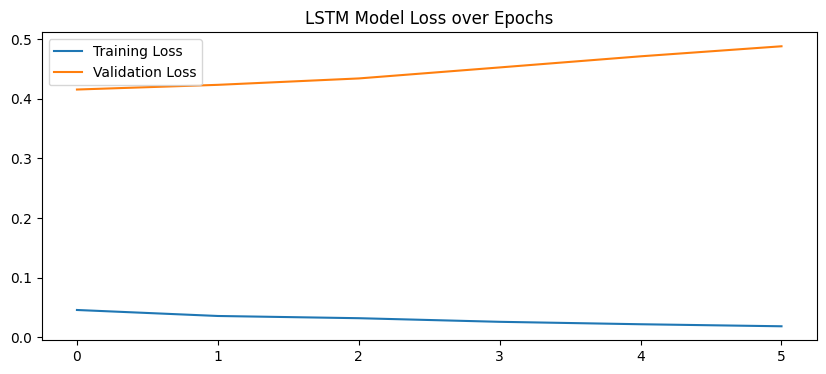

In [13]:
# Terminate training if validation loss degrades over 5 consecutive epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Preserve only the optimal model iteration using Keras 3.0 standards (.keras)
checkpoint = ModelCheckpoint('best_overlock_lstm.keras', monitor='val_accuracy', save_best_only=True)

print("Executing LSTM Model Training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Plot training convergence for thesis evaluation
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss over Epochs')
plt.legend()
plt.show()

#### Final Evaluation & Artifact Export for Live Inference

In [16]:
# Export preprocessing artifacts required for real-time inference pipeline
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

# Output final system accuracy metric
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8000 - loss: 0.4155

Final Test Accuracy: 80.00%
